In [1]:
import logging
from tqdm.notebook import tqdm
import pandas as pd
import numpy as np
import pandas as pd
import os
import pickle
from datetime import datetime
from ts_toolkit.pipeline.runner import TsPipeline
from ts_toolkit.pipeline.utils import load_config, forecast_output_saver

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
logging.basicConfig(level=logging.INFO)


/home/nafiseh/GitHub/timeseries-research/.venv/lib/python3.11/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore


In [2]:
%load_ext autoreload
%autoreload 2

### Data saving for plotting purposes

In [3]:
polished_path = f"results/polished_outputs/{datetime.now().strftime('%Y%m%d_%H%M%S')}/forecast_outputs.pkl"
os.makedirs(os.path.dirname(polished_path), exist_ok=True)

In [4]:
model_repertoire = {
    "Chronos2": {"name": "Chronos2", "params": { "batch_size": 64}},
    "Moirai": {"name": "Moirai", "params": {"repo_id": "Salesforce/moirai-1.1-R-large", "batch_size": 64}},
    "Toto": {"name": "Toto", "params": {"context_length": 4_096, "batch_size": 64}},
    # "Sundial": {"name": "Sundial", "params": { "batch_size": 64}},
}

config_dict = {
    "paths": {
        "storage_path": "data/simpletime/datasets_100",
        "output_path": "tmp_results"
    },
    "forecaster": None,
    "evaluation": {
        "to_univariate": False,
        "show_plot": False,
        "eval_substr": "dim0"
    },
}

for multivariate in [False, True]:
    if multivariate:
        multivariate_str = "Multivariate"
        config_dict["datasets"] = [
            {"name": "multivariate_lagged/normal", "term": "short"},
            {"name": "multivariate_lagged/random_walk", "term": "short"},
            {"name": "multivariate_lagged/intermittent", "term": "short"},
        ]
    else:
        multivariate_str = "Univariate"
        config_dict["datasets"] = [
            {"name": "univariate/linear", "term": "short"},
            {"name": "univariate/exponential", "term": "short"},
            {"name": "univariate/staircase", "term": "short"},
            {"name": "univariate/sine", "term": "short"},
            {"name": "univariate/fourier", "term": "short"},
            {"name": "univariate/growing_sine", "term": "short"},
        ]
        
    for model_name in model_repertoire.keys():
        config_dict["forecaster"] = {
            "name": "MedianEnsemble",
            "max_length": 512,
            "models": [model_repertoire[model_name]],
            "alias": f"{model_name}-{multivariate_str}-Full-Simpletime" # An identifier for your ensemble
        }
        config_dict["experiment_name"] = f"simpletime_{multivariate_str}_Full"
        config_dict["evaluation"]["to_univariate"] = not multivariate
        
        config = load_config(config_dict=config_dict) # config_path

        # --- Set up the evaluation pipeline ---
        pipeline = TsPipeline(config)
        # print(pipeline.get_forecast_horizons())
        pipeline.run(skip_existing=False, num_plots=1)
        # pipeline.get_results()
        agg_output_pickle = forecast_output_saver(pipeline, multivariate_str, model_name, polished_path)
        print('Datasets: ', agg_output_pickle[multivariate_str][model_name].keys())
        

INFO:ts_toolkit.pipeline.runner:   - Results will be saved to: /home/nafiseh/GitHub/timeseries-research/tmp_results/simpletime_Univariate_Full_20260212-161349/Chronos2-Univariate-Full-Simpletime
INFO:ts_toolkit.pipeline.runner:   - Datasets will be loaded from: /home/nafiseh/GitHub/timeseries-research/data/simpletime/datasets_100

INFO:ts_toolkit.pipeline.runner:
--- Starting Evaluation ---


Evaluating Datasets:   0%|          | 0/6 [00:00<?, ?it/s]

INFO:ts_toolkit.pipeline.eval:Dataset 'univariate/linear' has target_dim=1 => to_univariate is forced set to False.
INFO:ts_toolkit.pipeline.eval:Input: 2000-09-12T00:00:00.000000, label: 2000-09-12T00:00:00.000000, prediction length: 30
100it [00:00, 863.79it/s]
INFO:ts_toolkit.pipeline.eval:Results for univariate/linear have been written to /home/nafiseh/GitHub/timeseries-research/tmp_results/simpletime_Univariate_Full_20260212-161349/Chronos2-Univariate-Full-Simpletime/all_results.csv
INFO:ts_toolkit.pipeline.eval:Config has been written to /home/nafiseh/GitHub/timeseries-research/tmp_results/simpletime_Univariate_Full_20260212-161349/Chronos2-Univariate-Full-Simpletime/simpletime_Univariate_Full_20260212-161349_config.yaml
INFO:ts_toolkit.pipeline.eval:Dataset 'univariate/exponential' has target_dim=1 => to_univariate is forced set to False.
INFO:ts_toolkit.pipeline.eval:Input: 2000-09-12T00:00:00.000000, label: 2000-09-12T00:00:00.000000, prediction length: 30
100it [00:00, 921.03

Datasets:  dict_keys(['univariate/linear', 'univariate/exponential', 'univariate/staircase', 'univariate/sine', 'univariate/fourier', 'univariate/growing_sine'])


INFO:ts_toolkit.pipeline.runner:   - Results will be saved to: /home/nafiseh/GitHub/timeseries-research/tmp_results/simpletime_Univariate_Full_20260212-161349/simpletime_Univariate_Full_20260212-161403/Moirai-Univariate-Full-Simpletime
INFO:ts_toolkit.pipeline.runner:   - Datasets will be loaded from: /home/nafiseh/GitHub/timeseries-research/data/simpletime/datasets_100

INFO:ts_toolkit.pipeline.runner:
--- Starting Evaluation ---


...

INFO:ts_toolkit.pipeline.eval:Input: 2000-09-12T00:00:00.000000, label: 2000-09-12T00:00:00.000000, prediction length: 30
INFO:ts_toolkit.pipeline.runner:[{'name': 'Moirai', 'params': {'repo_id': 'Salesforce/moirai-1.1-R-large', 'batch_size': 64, 'target_dim': 2}}]
INFO:ts_toolkit.pipeline.runner:updated Moirai target dim with dataset target dim
INFO:gluonts.dataset.pandas:Indexing data by 'ds'.
INFO:gluonts.dataset.pandas:Grouping data by 'unique_id'; this may take some time.
100it [00:04, 22.71it/s]
100it [00:00, 907.80it/s]
INFO:ts_toolkit.pipeline.eval:Results for multivariate_lagged/normal have been written to /home/nafiseh/GitHub/timeseries-research/tmp_results/simpletime_Univariate_Full_20260212-161349/simpletime_Univariate_Full_20260212-161403/simpletime_Univariate_Full_20260212-161438/simpletime_Multivariate_Full_20260212-161939/simpletime_Multivariate_Full_20260212-162010/Moirai-Multivariate-Full-Simpletime/all_results.csv
INFO:ts_toolkit.pipeline.eval:Config has been written

Datasets:  dict_keys(['multivariate_lagged/normal', 'multivariate_lagged/random_walk', 'multivariate_lagged/intermittent'])


Evaluating Datasets:   0%|          | 0/3 [00:00<?, ?it/s]

INFO:ts_toolkit.pipeline.eval:Input: 2000-09-12T00:00:00.000000, label: 2000-09-12T00:00:00.000000, prediction length: 30
100%|██████████| 2/2 [01:27<00:00, 43.59s/it]
100it [00:00, 835.14it/s]
INFO:ts_toolkit.pipeline.eval:Results for multivariate_lagged/normal have been written to /home/nafiseh/GitHub/timeseries-research/tmp_results/simpletime_Univariate_Full_20260212-161349/simpletime_Univariate_Full_20260212-161403/simpletime_Univariate_Full_20260212-161438/simpletime_Multivariate_Full_20260212-161939/simpletime_Multivariate_Full_20260212-162010/simpletime_Multivariate_Full_20260212-162037/Toto-Multivariate-Full-Simpletime/all_results.csv
INFO:ts_toolkit.pipeline.eval:Config has been written to /home/nafiseh/GitHub/timeseries-research/tmp_results/simpletime_Univariate_Full_20260212-161349/simpletime_Univariate_Full_20260212-161403/simpletime_Univariate_Full_20260212-161438/simpletime_Multivariate_Full_20260212-161939/simpletime_Multivariate_Full_20260212-162010/simpletime_Multivari

Datasets:  dict_keys(['multivariate_lagged/normal', 'multivariate_lagged/random_walk', 'multivariate_lagged/intermittent'])


In [8]:
polished_path

'results/polished_outputs/20260212_161349/forecast_outputs.pkl'

In [44]:
import pickle
import numpy as np
# read the outputs from the file
polished_path = f"results/polished_outputs/20260212_161349/forecast_outputs.pkl"
with open(polished_path, "rb") as f:
    output_data = pickle.load(f)

for k, v in output_data.items():
    print(k, v.keys())
    # print a sample of the data
    for model_name, model_data in v.items():
        print(f"    Model: {model_name} w/ datasets: {model_data.keys()}")
        for dataset_name, dataset_data in model_data.items():
            for item_id, item_data in dataset_data.items():
                print(f"        Dataset: {dataset_name}")
                print(f"            item_id: {item_data['item_id']}")
                print(f"            dataset_label: {item_data['dataset_label']}")
                print(f"            Input sample shape: {np.array(item_data['input_list']).shape}")
                print(f"            Label sample shape: {np.array(item_data['label_list']).shape}")
                print(f"            Forecast sample length: {len(item_data['forecast_list'])}")
                break

Univariate dict_keys(['Chronos2', 'Moirai', 'Toto'])
    Model: Chronos2 w/ datasets: dict_keys(['univariate/linear', 'univariate/exponential', 'univariate/staircase', 'univariate/sine', 'univariate/fourier', 'univariate/growing_sine'])
        Dataset: univariate/linear
            item_id: linear_sample_000000
            dataset_label: univariate/linear
            Input sample shape: (1, 226)
            Label sample shape: (1, 30)
            Forecast sample length: 1
        Dataset: univariate/exponential
            item_id: exponential_sample_000000
            dataset_label: univariate/exponential
            Input sample shape: (1, 226)
            Label sample shape: (1, 30)
            Forecast sample length: 1
        Dataset: univariate/staircase
            item_id: staircase_sample_000000
            dataset_label: univariate/staircase
            Input sample shape: (1, 226)
            Label sample shape: (1, 30)
            Forecast sample length: 1
        Dataset:

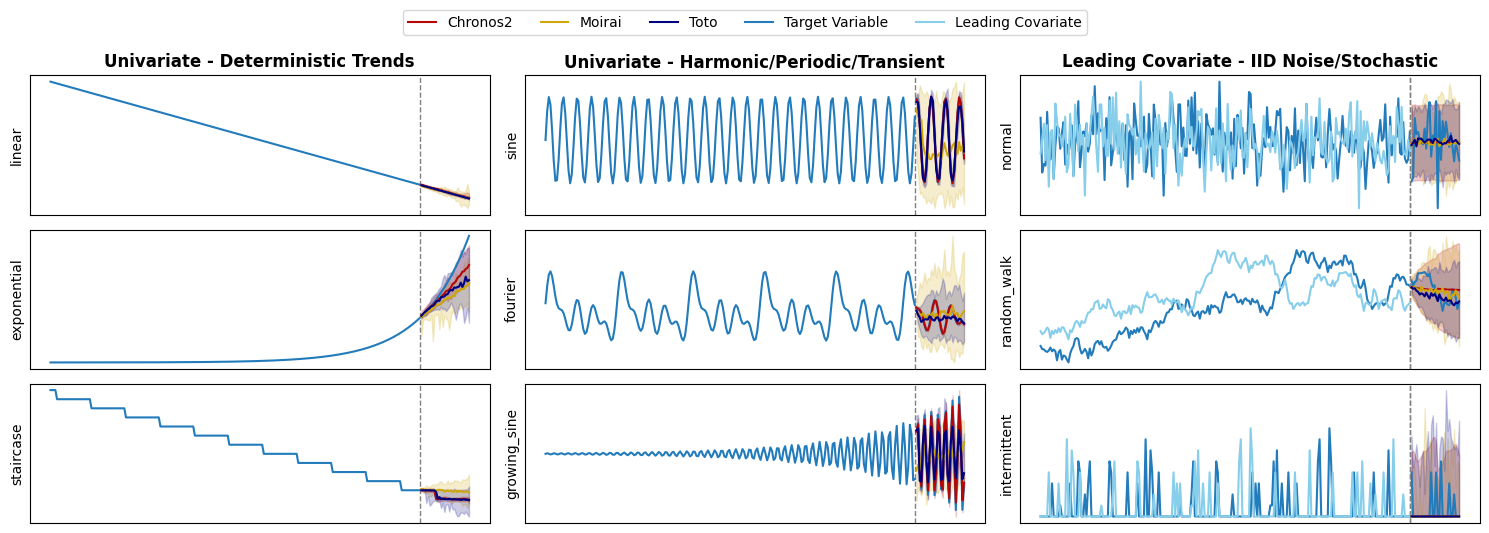

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from ts_toolkit.pipeline.viz_utils import colors
shade = True

selected_data_ids = {
    "multivariate_lagged/normal": "normal_sample_000002",
    "multivariate_lagged/random_walk": "random_walk_sample_000003",
    "multivariate_lagged/intermittent": "intermittent_sample_000000",
    "univariate/linear": "linear_sample_000004",
    "univariate/exponential": "exponential_sample_000000",
    "univariate/staircase": "staircase_sample_000004",
    "univariate/sine": "sine_sample_000008",
    "univariate/fourier": "fourier_sample_000004",
    "univariate/growing_sine": "growing_sine_sample_000007",
}

# grid plot of all figures, overlapping the plots for different models, one column for univariate and one for multivariate
## Samples from all distributions
grid_fig, grid_axes = plt.subplots(3, 3, figsize=(15, 5))

dataset_indices = {key: i for var_str in output_data.keys() for i, key in enumerate(output_data[var_str]["Chronos2"].keys())}

for multivar_idx, (multivariate_str, var_outputs) in enumerate(output_data.items()):
    for model_idx, (model_name, model_outputs) in enumerate(var_outputs.items()):
        for dataset_name, list_output in model_outputs.items():
            if dataset_name in selected_data_ids and selected_data_ids[dataset_name]:
                data_output_key = selected_data_ids[dataset_name]
            else:
                data_output_key = np.random.choice(list(list_output.keys())) # randomly select one dataset to plot for each model
                selected_data_ids[dataset_name] = data_output_key
                print(f"{list_output[data_output_key]['item_id']} selected.")
            data_output = list_output[data_output_key]
                
            # data_output keys: 'dataset_label', 'input_list', 'label_list', 'forecast_list', 'data', 'item_id'
            _dataset_name, input_list, label_list, forecast_list, data, item_id = data_output.values()
            assert dataset_name == _dataset_name, "Dataset name mismatch!"
            data_idx = dataset_indices[dataset_name]
            if grid_axes.ndim == 1:
                grid_axes[0].set_title("Univariate - Deterministic Trends")
                grid_axes[1].set_title("Univariate - Harmonic/Periodic/Transient")
                grid_axes[2].set_title("Leading Covariate - IID Noise/Stochastic")
                for j in range(3):
                    # make title bold   
                    grid_axes[j].title.set_fontweight('bold')
                    grid_axes[j].title.set_fontsize(12)
                ax = grid_axes[1] if multivariate_str == "Multivariate" else grid_axes[0]
                
            else:
                if data_idx == 0:
                    grid_axes[data_idx, 0].set_title("Univariate - Deterministic Trends")
                    grid_axes[data_idx, 1].set_title("Univariate - Harmonic/Periodic/Transient")
                    grid_axes[data_idx, 2].set_title("Leading Covariate - IID Noise/Stochastic")
                    for j in range(3):
                        # make title bold   
                        grid_axes[data_idx, j].title.set_fontweight('bold')
                        grid_axes[data_idx, j].title.set_fontsize(12)
                # get the axis
                ax = grid_axes[data_idx, 2] if multivariate_str == "Multivariate" else grid_axes[data_idx, 0] if data_idx < 3 else grid_axes[data_idx-3, 1]
            
            
                
            
            # plot_one_axis(ax, input_list, label_list, forecast_list, data, colors, shade=shade)
            for var, (input, label, fcst) in enumerate(zip(input_list, label_list, forecast_list)):
                if model_idx == 0:
                    for lbl, target in zip(["input", "label"], [input, label]):
                        if var !=0 and lbl == "label": # only plot input for the input to avoid clutter
                            continue
                        k = 0 if lbl == "input" else 1
                        dates = pd.date_range(
                            start=data[k]["start"].to_timestamp(), periods=target.size, freq=data[k]["freq"],
                        )
                        if lbl == "input":
                            ax.axvline(x=dates[-1], color=colors["boundary"], linestyle="--", linewidth=1)
                        ax.plot(
                            dates, target, 
                            color=colors["input"] if var == 0 else colors["leading_covariate"], 
                            label=(f"Target Variable" if var == 0 else "Leading Covariate") if (lbl == "input" and data_idx == 0 and multivariate_str == "Multivariate") else None,
                            # linewidth = 3 if var == 0 else 2
                        )
                if var == 0: # only plot forecast for the first variable to avoid clutter
                    # if model_idx != 0:
                    #     continue
                    median_forecast = fcst.median
                    forecast_dates = pd.date_range(
                        start=fcst.start_date.to_timestamp(), periods=len(median_forecast), freq=fcst.start_date.freqstr,
                    )
                    ax.plot(
                        forecast_dates, median_forecast, color=colors[model_name], #linewidth=2,
                        label=f"{model_name}" if (data_idx == 0 and multivar_idx == 0) else None,
                    )
                    if shade:
                        alpha = 0.05
                        lower = fcst.quantile(alpha)
                        upper = fcst.quantile(1 - alpha)
                        ax.fill_between(forecast_dates, lower, upper, color=colors[model_name], alpha=0.2)
            # remove x ticks
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_ylabel(dataset_name.split("/")[-1])

# sort the legend in this order: "Target Variable", "Leading Covariate", "Model A", "Model B"
desired_order = ["Target Variable", "Leading Covariate"]

# Extract handles and labels from all axes
axes_handles_labels = [ax.get_legend_handles_labels() for ax in grid_axes.flatten()]
handles_labels = [hl for hl in axes_handles_labels if hl[1]]  # filter out axes with no labels
handles, labels = zip(*handles_labels)

# Flatten handles and labels
handles = [h for sublist in handles for h in sublist]
labels = [l for sublist in labels for l in sublist]

# Create a mapping of labels to handles
label_handle_map = dict(zip(labels, handles))

# Sort handles and labels based on the desired order, with remaining labels in alphabetical order
sorted_handles = [label_handle_map[label] for label in desired_order if label in label_handle_map]
sorted_labels = [label for label in desired_order if label in label_handle_map]

# Add remaining labels in alphabetical order
remaining_labels = sorted(set(labels) - set(desired_order))
sorted_handles.extend([label_handle_map[label] for label in remaining_labels])
sorted_labels.extend(remaining_labels)

# Add one legend for the entire figure outside the grid
# grid_fig.legend(sorted_handles, sorted_labels, loc='upper center', ncol=1, bbox_to_anchor=[0.965, 0.95])
grid_fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.07), ncol=5, frameon=True)
grid_fig.tight_layout()
plt.savefig('results_shared/TSALM2025_paper/simpletime_uni_multi_gridplot.pdf', bbox_inches='tight')